In [11]:
%pip cache purge

%pip install pandas

%pip install numpy

%pip install kagglehub

%pip install matplotlib

%pip install ipywidgets

import sys
print(sys.version)


In [12]:
# Simple linear Regression

%pip install pandas

import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
# get a dataset from kaggle to apply a Simple linear Regression Model 
# Download latest version
path = kagglehub.dataset_download("shubham47/salary-data-dataset-for-linear-regression")

print("Path to dataset files:", path)
path_data="/Users/raeshadev/.cache/kagglehub/datasets/shubham47/salary-data-dataset-for-linear-regression/versions/1/Salary_Data.csv" 

Note: you may need to restart the kernel to use updated packages.
Path to dataset files: /Users/reesha/.cache/kagglehub/datasets/shubham47/salary-data-dataset-for-linear-regression/versions/1


In [29]:
ds = pd.read_csv(path_data)
X = ds["YearsExperience"].values
Y = ds["Salary"].values

Y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

In [30]:

X


array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

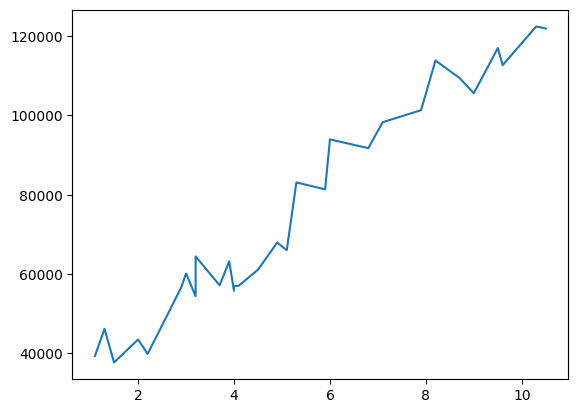

In [33]:
plt.plot(X,Y)
X=np.array(X)
Y=np.array(Y)

In [34]:
def mean(X):
    return  np.sum(X)/len(X)

In [39]:
def variance(X):
    mean_value=mean(X)
    return np.sum((X-mean_value)**2)/len(X)

In [40]:
def norm(X):
    var=variance(X)
    return (X-mean(X))/np.sqrt(var)

In [41]:
X_norm=norm(X)


In [42]:
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

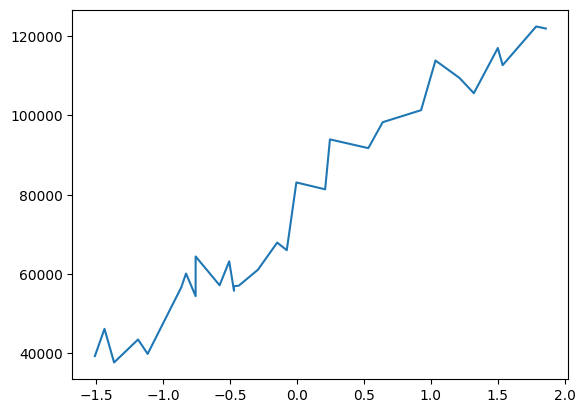

In [43]:
plt.plot(X_norm,Y)

In [44]:
import random

In [50]:
class SimpleLR:
    def __init__(self,lr=0.1, max_iter=2000,threshold=1e-6):
        self.lr=lr
        self.max_iter=max_iter
        self.threshold=threshold
        self.weight=random.uniform(-1,1)
        self.bias=random.uniform(-1,1)
    #predict
    def predict(self, X):
        return self.weight*X + self.bias
    #checks how are data fits the model or fits the model to the data   
    def fit(self,X,Y):
        n=len(X)
        loss_hist=[]
        y_pred=self.predict(X)
        err=Y-y_pred
        prev_loss=(1/(2*n))*np.sum(err**2)
        for i in range(self.max_iter):
            w_grad=(1/n)*np.sum(err*X)
            b_grad=(1/n)*np.sum(err)
            self.weight+=self.lr*w_grad
            self.bias+=self.lr*b_grad
            y_pred=self.predict(X)
            err=Y-y_pred
            curr_loss=(1/(2*n))*np.sum(err**2)
            if np.abs(curr_loss-prev_loss)<self.threshold:
                break
            prev_loss=curr_loss
            loss_hist.append(curr_loss)
        return loss_hist

    def plot(self, X, Y):
        y_pred=self.predict(X)
        plt.plot(X,Y)
        plt.plot(X,y_pred)

In [51]:
model = SimpleLR()

In [52]:
loss_hist = model.fit(X_norm,Y)

In [53]:
loss_hist

[np.float64(2636696700.588047),
 np.float64(2138695067.8899348),
 np.float64(1735313745.404464),
 np.float64(1408574874.1912322),
 np.float64(1143916388.5085151),
 np.float64(929543015.1055139),
 np.float64(755900582.6490828),
 np.float64(615250212.3593736),
 np.float64(501323412.42470944),
 np.float64(409042704.4776313),
 np.float64(334295331.04049796),
 np.float64(273749958.55642015),
 np.float64(224708206.84431705),
 np.float64(184984387.95751357),
 np.float64(152808094.6592027),
 np.float64(126745297.08757089),
 np.float64(105634431.05454908),
 np.float64(88534629.56780146),
 np.float64(74683790.36353591),
 np.float64(63464610.608080745),
 np.float64(54377075.006162144),
 np.float64(47016171.16860803),
 np.float64(41053839.06018918),
 np.float64(36224350.05236992),
 np.float64(32312463.95603634),
 np.float64(29143836.218006104),
 np.float64(26577247.75020162),
 np.float64(24498311.091279984),
 np.float64(22814372.397553455),
 np.float64(21450382.05563497),
 np.float64(20345549.8786

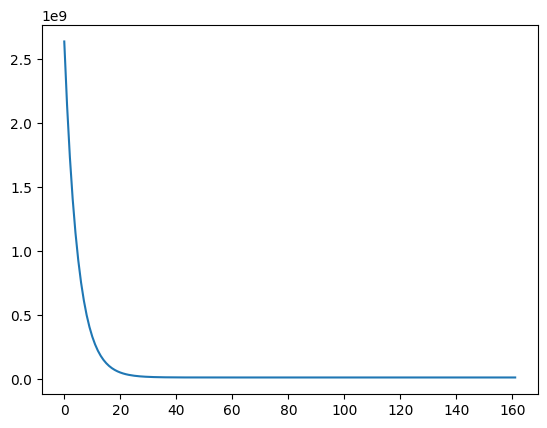

In [54]:
plt.plot(loss_hist)

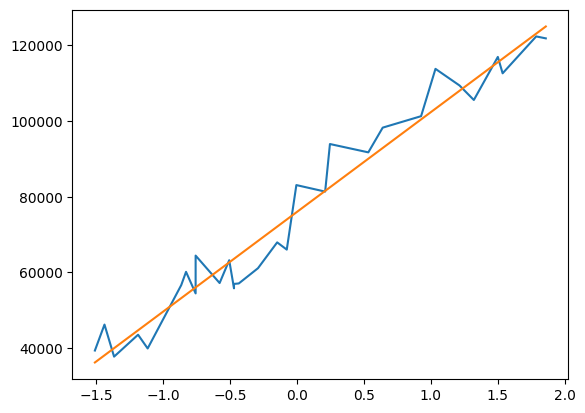

In [55]:
# we got max iterations as 160.

model.plot(X_norm, Y)